# moabb4 — Full Pipeline Benchmark (All train.py Pipelines)

Benchmarks **all 11 pipelines** from `train.py` on **8-channel** and **22-channel** configurations.
Protocol: within-subject 5-fold stratified CV.  Dataset: `BNCI2014_001`, 9 subjects.

| Family | Pipelines |
|---|---|
| Riemannian TS | cov_ts_lr, cov_ts_svm, cov_ts_mlp, cov_mdm |
| Augmented TS  | aug_ts_lr, aug_ts_svm, aug_ts_mlp |
| CSP           | csp_svm, csp_lda, csp_rf, csp_mlp |

In [ ]:
!pip install moabb

Defaulting to user installation because normal site-packages is not writeable
  Using cached moabb-1.5.0-py3-none-any.whl.metadata (14 kB)
  Using cached memory_profiler-0.61.0-py3-none-any.whl.metadata (20 kB)
  Using cached EDFlib_Python-1.0.8-py3-none-any.whl.metadata (1.3 kB)
  Using cached edfio-0.4.13-py3-none-any.whl.metadata (4.0 kB)
  Using cached pytest-9.0.3-py3-none-any.whl.metadata (7.6 kB)
  Using cached mne_bids-0.18.0-py3-none-any.whl.metadata (7.9 kB)
  Using cached pybv-0.7.6-py3-none-any.whl.metadata (14 kB)
  Using cached pycountry-26.2.16-py3-none-any.whl.metadata (12 kB)
  Using cached docstring_inheritance-3.0.0-py3-none-any.whl.metadata (10 kB)
  Using cached xmltodict-1.0.4-py3-none-any.whl.metadata (14 kB)
  Using cached iniconfig-2.3.0-py3-none-any.whl.metadata (2.5 kB)
  Using cached pluggy-1.6.0-py3-none-any.whl.metadata (4.8 kB)
Using cached moabb-1.5.0-py3-none-any.whl (837 kB)
Using cached docstring_inheritance-3.0.0-py3-none-any.whl (26 kB)
Using cached


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\zaelux\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import warnings; warnings.filterwarnings('ignore')
import mne
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from IPython.display import display

import moabb
from moabb.datasets import BNCI2014_001
from moabb.paradigms import LeftRightImagery
moabb.set_log_level('info')

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from mne.decoding import CSP
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from pyriemann.classification import MDM

# ── Paths — notebook lives in src/notebooks/, outputs go to PythonBCI/models ─
# Do NOT override MNE_DATA — reuse the same cache as moabb3_apples_to_apples
NB_DIR    = Path.cwd()  # src/notebooks/ when run from VS Code
MODEL_DIR = NB_DIR.parent.parent / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print(f'Outputs: {MODEL_DIR}')
print(f'MNE data: {mne.get_config("MNE_DATA", "(default)")}' )

# ── Global plot aesthetics ─────────────────────────────────────────────────────
mpl.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
})
sns.set_style('whitegrid')
SEED = 42
np.random.seed(SEED)
print('Setup complete.')


Outputs: e:\GitHub\brainwave-surfers\PythonBCI\models
MNE data: C:\Users\zaelux\mne_data
Setup complete.


## 1. Pipeline Definitions (mirrors train.py exactly)

In [7]:
class AugmentedDataset(BaseEstimator, TransformerMixin):
    """Delay-embedding augmentation — identical to train.py."""
    def __init__(self, order=2, lag=1):
        self.order = order; self.lag = lag
    def fit(self, X, y=None): return self
    def transform(self, X):
        if self.order <= 1: return X
        chunks = []
        for p in range(self.order):
            s = p * self.lag
            e = X.shape[2] - (self.order - 1 - p) * self.lag
            chunks.append(X[:, :, s:e])
        return np.concatenate(chunks, axis=1)


def make_pipelines():
    LR  = lambda C=1.0: LogisticRegression(C=C, max_iter=2000, solver='lbfgs', random_state=SEED)
    SVM = lambda C=1.0, k='rbf': SVC(C=C, kernel=k, probability=True, random_state=SEED)
    MLP = lambda h=(100,): MLPClassifier(hidden_layer_sizes=h, max_iter=2000, random_state=SEED)
    CSP4 = lambda: CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=False)
    COV  = lambda e='oas': Covariances(estimator=e)
    TS   = lambda: TangentSpace(metric='riemann')
    SC   = StandardScaler
    return {
        # Riemannian Tangent Space
        'cov_ts_lr':  Pipeline([('cov',COV()),('ts',TS()),('sc',SC()),('clf',LR())]),
        'cov_ts_svm': Pipeline([('cov',COV()),('ts',TS()),('sc',SC()),('clf',SVM())]),
        'cov_ts_mlp': Pipeline([('cov',COV()),('ts',TS()),('sc',SC()),('clf',MLP())]),
        'cov_mdm':    Pipeline([('cov',COV()),('clf',MDM(metric='riemann'))]),
        # Augmented TS (delay embedding)
        'aug_ts_lr':  Pipeline([('aug',AugmentedDataset(2)),('cov',COV('lwf')),('ts',TS()),('sc',SC()),('clf',LR(0.1))]),
        'aug_ts_svm': Pipeline([('aug',AugmentedDataset(2)),('cov',COV()),('ts',TS()),('sc',SC()),('clf',SVM())]),
        'aug_ts_mlp': Pipeline([('aug',AugmentedDataset(2)),('cov',COV()),('ts',TS()),('sc',SC()),('clf',MLP())]),
        # CSP
        'csp_svm':    Pipeline([('csp',CSP4()),('clf',SVM())]),
        'csp_lda':    Pipeline([('csp',CSP4()),('clf',LDA())]),
        'csp_rf':     Pipeline([('csp',CSP4()),('clf',RandomForestClassifier(100,random_state=SEED))]),
        'csp_mlp':    Pipeline([('csp',CSP4()),('clf',MLP())]),
    }

PIPELINES  = make_pipelines()
PIPE_ORDER = list(PIPELINES.keys())
FAMILY = {
    'cov_ts_lr':'Riemannian','cov_ts_svm':'Riemannian',
    'cov_ts_mlp':'Riemannian','cov_mdm':'Riemannian',
    'aug_ts_lr':'Aug-TS','aug_ts_svm':'Aug-TS','aug_ts_mlp':'Aug-TS',
    'csp_svm':'CSP','csp_lda':'CSP','csp_rf':'CSP','csp_mlp':'CSP',
}
print(f'{len(PIPELINES)} pipelines ready: {PIPE_ORDER}')


11 pipelines ready: ['cov_ts_lr', 'cov_ts_svm', 'cov_ts_mlp', 'cov_mdm', 'aug_ts_lr', 'aug_ts_svm', 'aug_ts_mlp', 'csp_svm', 'csp_lda', 'csp_rf', 'csp_mlp']


## 2. Data Extraction
Uses the same default MOABB cache as `moabb3_apples_to_apples` — no re-download needed.

In [5]:
UHB_CHANNELS = ['FC3','C3','CP3','Cz','CPz','FC4','C4','CP4']
SFREQ        = 250
DATASET_TAG  = 'BNCI2014001'

dataset      = BNCI2014_001()
SUBJECTS     = dataset.subject_list
print('Subjects:', SUBJECTS)

paradigm_8ch  = LeftRightImagery(channels=UHB_CHANNELS, resample=SFREQ)
paradigm_22ch = LeftRightImagery(resample=SFREQ)

print('Extracting 8-channel data...')
X_8,  y_8,  meta_8  = paradigm_8ch.get_data(dataset=dataset, subjects=SUBJECTS)
print('Extracting 22-channel data...')
X_22, y_22, meta_22 = paradigm_22ch.get_data(dataset=dataset, subjects=SUBJECTS)

le       = LabelEncoder()
y_8_num  = le.fit_transform(y_8)
y_22_num = le.fit_transform(y_22)

CONFIGS = {
    '8ch':  {'X': X_8,  'y': y_8_num,  'meta': meta_8},
    '22ch': {'X': X_22, 'y': y_22_num, 'meta': meta_22},
}
print(f'\n8ch  shape: {X_8.shape}')
print(f'22ch shape: {X_22.shape}')


Subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Extracting 8-channel data...
Extracting 22-channel data...

8ch  shape: (2592, 8, 1001)
22ch shape: (2592, 22, 1001)


## 3. Within-Subject 5-Fold CV
Results cached to `PythonBCI/models/BNCI2014001_moabb4_results.csv`.  Set `force_rerun=True` to re-evaluate.

In [8]:
RESULTS_CSV  = MODEL_DIR / f'{DATASET_TAG}_moabb4_results.csv'
force_rerun  = False  # set True to ignore cache

def run_benchmark(configs, pipelines, subjects, n_splits=5):
    if RESULTS_CSV.exists() and not force_rerun:
        print(f'[CACHE] Loading {RESULTS_CSV.name}')
        return pd.read_csv(RESULTS_CSV)

    cv   = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    rows = []
    for ch_tag, d in configs.items():
        X, y, meta = d['X'], d['y'], d['meta']
        for pipe_name, pipeline in pipelines.items():
            print(f'  [{ch_tag}] {pipe_name}', flush=True)
            for subj in subjects:
                idx   = meta['subject'].astype(str) == str(subj)
                X_s, y_s = X[idx], y[idx]
                try:
                    cv_r = cross_validate(
                        clone(pipeline), X_s, y_s, cv=cv,
                        scoring=['accuracy','roc_auc'], n_jobs=-1
                    )
                    rows.append({
                        'pipeline': pipe_name, 'channels': ch_tag, 'subject': subj,
                        'accuracy': float(np.mean(cv_r['test_accuracy'])),
                        'roc_auc':  float(np.mean(cv_r['test_roc_auc'])),
                    })
                except Exception as exc:
                    print(f'    SKIP subj={subj}: {exc}')

    df = pd.DataFrame(rows)
    df.to_csv(RESULTS_CSV, index=False)
    print(f'Saved: {RESULTS_CSV}')
    return df

df_all   = run_benchmark(CONFIGS, PIPELINES, SUBJECTS)
df_means = (
    df_all.groupby(['pipeline','channels'])[['accuracy','roc_auc']]
    .mean().round(3).reset_index()
)
df_means['family'] = df_means['pipeline'].map(FAMILY)
print('\nGlobal means:')
display(df_means.sort_values('roc_auc', ascending=False).to_string(index=False))


[CACHE] Loading BNCI2014001_moabb4_results.csv

Global means:


'  pipeline channels  accuracy  roc_auc     family\naug_ts_svm     22ch     0.838    0.898     Aug-TS\n aug_ts_lr     22ch     0.835    0.894     Aug-TS\naug_ts_mlp     22ch     0.829    0.887     Aug-TS\ncov_ts_svm     22ch     0.809    0.873 Riemannian\ncov_ts_mlp     22ch     0.799    0.861 Riemannian\n cov_ts_lr     22ch     0.790    0.856 Riemannian\n aug_ts_lr      8ch     0.794    0.855     Aug-TS\naug_ts_svm      8ch     0.796    0.854     Aug-TS\naug_ts_mlp      8ch     0.778    0.852     Aug-TS\n   csp_mlp     22ch     0.786    0.836        CSP\n   csp_lda     22ch     0.782    0.834        CSP\n   csp_svm     22ch     0.781    0.824        CSP\n cov_ts_lr      8ch     0.764    0.819 Riemannian\ncov_ts_svm      8ch     0.758    0.813 Riemannian\n    csp_rf     22ch     0.761    0.807        CSP\ncov_ts_mlp      8ch     0.741    0.806 Riemannian\n   csp_mlp      8ch     0.762    0.801        CSP\n   csp_lda      8ch     0.753    0.801        CSP\n   csp_svm      8ch     0.750 

## 4. Visualizations

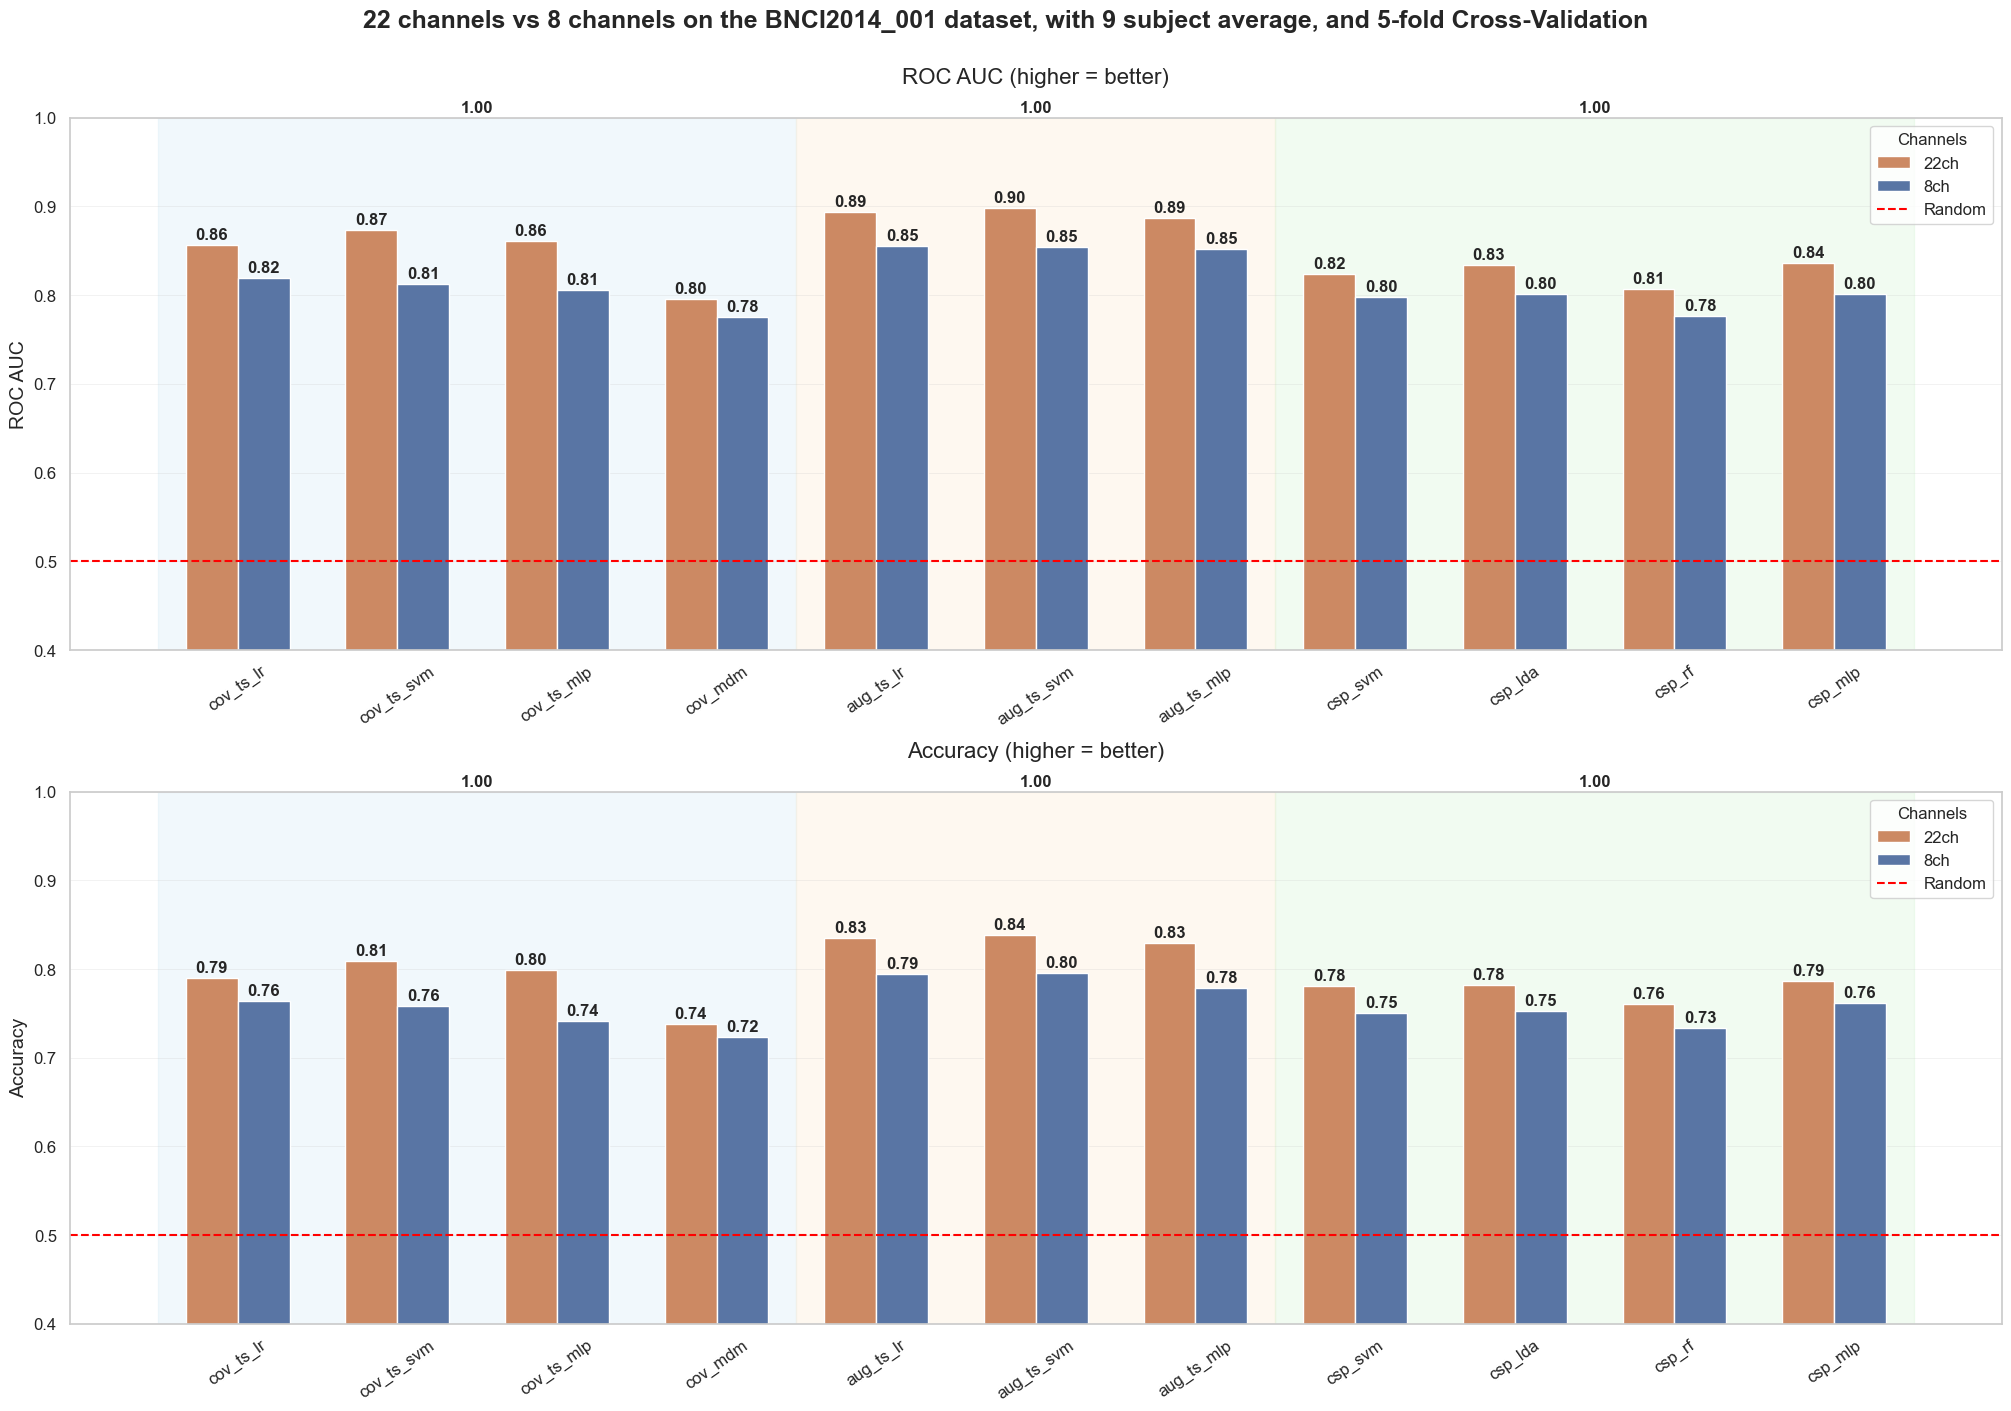

In [45]:
PALETTE  = {'8ch':'#4C72B0','22ch':'#DD8452'}
# Updated with more distinct pastel colors
BG_COLOR = {'Riemannian':'#D1E9F6', 'Aug-TS':'#FEEBD0', 'CSP':'#D1F2D1'}

def add_family_shading(ax, pipe_order, family_map):
    families = [family_map[p] for p in pipe_order]
    i, prev  = 0, families[0]
    for j, fam in enumerate(families + [None]):
        if fam != prev:
            # Increased alpha slightly and removed the ax.text call
            ax.axvspan(i-.5, j-.5, alpha=0.3, color=BG_COLOR[prev], zorder=0)
            i, prev = j, fam

def value_labels(ax, fontsize=12):
    for bar in ax.patches:
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x()+bar.get_width()/2, h+0.003,
                    f'{h:.2f}', ha='center', va='bottom',
                    fontsize=fontsize, fontweight='bold')

# ─── Main comparison: 8ch vs 22ch, all pipelines ─────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(20, 14), constrained_layout=True)
fig.suptitle('22 channels vs 8 channels on the BNCI2014_001 dataset, with 9 subject average, and 5-fold Cross-Validation\n',
             fontsize=18, fontweight='bold')

for ax, metric, title in zip(axes,
        ['roc_auc','accuracy'], ['ROC AUC (higher = better)\n','Accuracy (higher = better)\n']):
    sns.barplot(
        data=df_means, x='pipeline', y=metric, hue='channels',
        order=PIPE_ORDER, palette=PALETTE, ax=ax, width=0.65
    )
    ax.axhline(0.5, ls='--', color='red', lw=1.5, label='Random')
    ax.set_ylim(0.40, 1.0)
    ax.set_title(title, fontsize=16, pad=8)
    ax.set_xlabel('')
    ax.set_ylabel(title.split(' (')[0], fontsize=14)
    ax.tick_params(axis='x', rotation=35, labelsize=12)
    ax.legend(title='Channels', fontsize=12, title_fontsize=12)
    add_family_shading(ax, PIPE_ORDER, FAMILY)
    value_labels(ax)

plt.savefig(MODEL_DIR/f'{DATASET_TAG}_moabb4_pipeline_comparison.png',
            dpi=300, bbox_inches='tight')
plt.savefig(MODEL_DIR/f'{DATASET_TAG}_moabb4_bars.svg', format='svg', bbox_inches='tight')
plt.show()


2026-05-07 14:08:53,891 INFO MainThread fontTools.subset maxp pruned
2026-05-07 14:08:53,893 INFO MainThread fontTools.subset LTSH dropped
2026-05-07 14:08:53,893 INFO MainThread fontTools.subset cmap pruned
2026-05-07 14:08:53,894 INFO MainThread fontTools.subset kern dropped
2026-05-07 14:08:53,894 INFO MainThread fontTools.subset post pruned
2026-05-07 14:08:53,895 INFO MainThread fontTools.subset PCLT dropped
2026-05-07 14:08:53,895 INFO MainThread fontTools.subset JSTF dropped
2026-05-07 14:08:53,895 INFO MainThread fontTools.subset meta dropped
2026-05-07 14:08:53,903 INFO MainThread fontTools.subset GPOS pruned
2026-05-07 14:08:53,907 INFO MainThread fontTools.subset GSUB pruned
2026-05-07 14:08:53,914 INFO MainThread fontTools.subset glyf pruned
2026-05-07 14:08:53,916 INFO MainThread fontTools.subset Added gid0 to subset
2026-05-07 14:08:53,916 INFO MainThread fontTools.subset Added first four glyphs to subset
2026-05-07 14:08:53,917 INFO MainThread fontTools.subset Closing gl

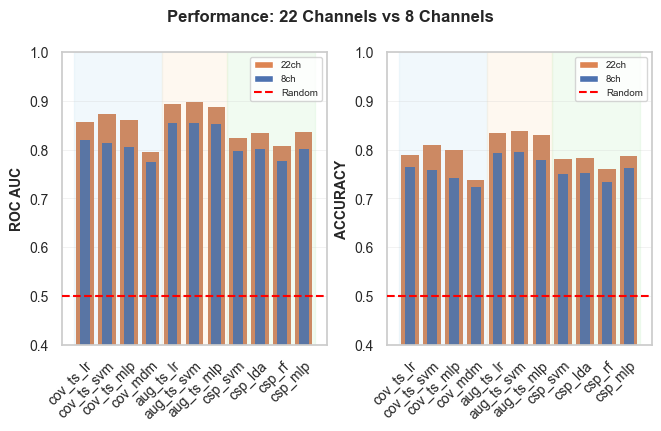

In [82]:
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ─── Overleaf/LaTeX Dimension Match (6.5" width) ────────────────────────────
mpl.rcParams['pdf.fonttype'] = 42

# 6.5 inches matches a standard LaTeX text width perfectly.
# 13pt here will now equal ~13pt in your PDF.
fig, axes = plt.subplots(1, 2, figsize=(6.5, 4.2), constrained_layout=True)

# Forcing the smallest font to be exactly 13pt
SMALL_FONT = 10
MEDIUM_FONT = 12

fig.suptitle('Performance: 22 Channels vs 8 Channels', fontsize=MEDIUM_FONT, fontweight='bold')

for ax, metric, title in zip(axes, metrics, titles):
    d22 = df_means[df_means['channels'] == '22ch']
    d8  = df_means[df_means['channels'] == '8ch']
    
    # Overlapping bars
    sns.barplot(data=d22, x='pipeline', y=metric, order=PIPE_ORDER, 
                color=PALETTE['22ch'], ax=ax, width=0.8, edgecolor='none')
    sns.barplot(data=d8, x='pipeline', y=metric, order=PIPE_ORDER, 
                color=PALETTE['8ch'], ax=ax, width=0.45, edgecolor='none')
    
    ax.axhline(0.5, ls='--', color='red', lw=1.5, zorder=5)
    
    # Data Labels (13pt)
    # Adjusted padding for the smaller canvas
    # ax.bar_label(ax.containers[0], fmt='%.2f', padding=2, 
    #             fontsize=SMALL_FONT-4, fontweight='bold', color=PALETTE['22ch'])
    
    #ax.bar_label(ax.containers[1], fmt='%.2f', padding=-20, 
    #             fontsize=SMALL_FONT-4, fontweight='bold', color='white')
    
    # Axes Styling
    ax.set_title(title, fontsize=SMALL_FONT, fontweight='bold')
    ax.set_ylabel(metric.replace('_', ' ').upper(), fontsize=SMALL_FONT, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylim(0.4, 1.0) 
    
    # Tick Labels (Forced to 13pt)
    ax.tick_params(axis='x', rotation=45, labelsize=SMALL_FONT)
    ax.tick_params(axis='y', labelsize=SMALL_FONT)

    plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")
    
    # Legend
    legend_elements = [
        Patch(facecolor=PALETTE['22ch'], label='22ch'),
        Patch(facecolor=PALETTE['8ch'], label='8ch'),
        Line2D([0], [0], color='red', ls='--', lw=1.5, label='Random')
    ]
    # Smaller legend padding for tight side-by-side layout
    ax.legend(handles=legend_elements, fontsize=SMALL_FONT-3, loc='upper right', frameon=True)
    
    add_family_shading(ax, PIPE_ORDER, FAMILY)

# Save for Overleaf
plt.savefig(MODEL_DIR/f'{DATASET_TAG}_moabb4_bars.pdf', bbox_inches='tight')
plt.show()


2026-05-07 14:22:23,508 INFO MainThread fontTools.subset maxp pruned
2026-05-07 14:22:23,508 INFO MainThread fontTools.subset LTSH dropped
2026-05-07 14:22:23,509 INFO MainThread fontTools.subset cmap pruned
2026-05-07 14:22:23,509 INFO MainThread fontTools.subset kern dropped
2026-05-07 14:22:23,510 INFO MainThread fontTools.subset post pruned
2026-05-07 14:22:23,510 INFO MainThread fontTools.subset PCLT dropped
2026-05-07 14:22:23,510 INFO MainThread fontTools.subset JSTF dropped
2026-05-07 14:22:23,511 INFO MainThread fontTools.subset meta dropped
2026-05-07 14:22:23,517 INFO MainThread fontTools.subset GPOS pruned
2026-05-07 14:22:23,522 INFO MainThread fontTools.subset GSUB pruned
2026-05-07 14:22:23,530 INFO MainThread fontTools.subset glyf pruned
2026-05-07 14:22:23,531 INFO MainThread fontTools.subset Added gid0 to subset
2026-05-07 14:22:23,532 INFO MainThread fontTools.subset Added first four glyphs to subset
2026-05-07 14:22:23,532 INFO MainThread fontTools.subset Closing gl

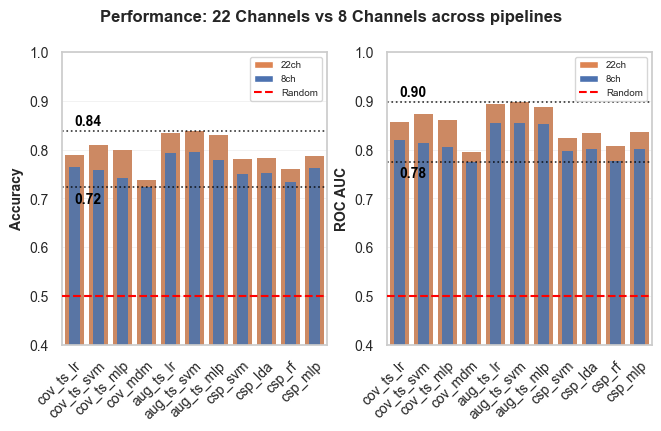

In [101]:
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ─── Final Visualization with Performance Bounds ────────────────────────────
mpl.rcParams['pdf.fonttype'] = 42

fig, axes = plt.subplots(1, 2, figsize=(6.5, 4.2), constrained_layout=True)

SMALL_FONT = 10
MEDIUM_FONT = 12

y_labels = ['Accuracy', 'ROC AUC']
fig.suptitle('Performance: 22 Channels vs 8 Channels across pipelines', fontsize=MEDIUM_FONT, fontweight='bold')

for ax, metric, y_label, title in zip(axes, metrics, y_labels, titles):
    d22 = df_means[df_means['channels'] == '22ch']
    d8  = df_means[df_means['channels'] == '8ch']
    
    # Overlapping bars
    sns.barplot(data=d22, x='pipeline', y=metric, order=PIPE_ORDER, 
                color=PALETTE['22ch'], ax=ax, width=0.8, edgecolor='none')
    sns.barplot(data=d8, x='pipeline', y=metric, order=PIPE_ORDER, 
                color=PALETTE['8ch'], ax=ax, width=0.45, edgecolor='none')
    
    # Base Chance line
    ax.axhline(0.5, ls='--', color='red', lw=1.5, zorder=5)

    # 1. Best performing 22ch (Upper Bound)
    best_22 = d22[metric].max()
    ax.axhline(best_22, ls=':', color="black", lw=1.2, alpha=0.8)
    ax.text(0, best_22 + 0.005, f'{best_22:.2f}', color="black", 
            fontsize=SMALL_FONT, fontweight='bold', va='bottom', ha='left')

    # 2. Worst performing 8ch (Lower Bound)
    worst_8 = d8[metric].min()
    ax.axhline(worst_8, ls=':', color="black", lw=1.2, alpha=0.8)
    ax.text(0, worst_8 - 0.01, f'{worst_8:.2f}', color="black", 
            fontsize=SMALL_FONT, fontweight='bold', va='top', ha='left')
    
    # Styling and formatting
    
    ax.set_title(title, fontsize=SMALL_FONT, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=SMALL_FONT, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylim(0.4, 1.0) 
    
    ax.tick_params(axis='x', rotation=45, labelsize=SMALL_FONT)
    ax.tick_params(axis='y', labelsize=SMALL_FONT)
    plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")
    
    legend_elements = [
        Patch(facecolor=PALETTE['22ch'], label='22ch'),
        Patch(facecolor=PALETTE['8ch'], label='8ch'),
        Line2D([0], [0], color='red', ls='--', lw=1.5, label='Random')
    ]
    ax.legend(handles=legend_elements, fontsize=SMALL_FONT-3, loc='upper right', frameon=True)
    
    #add_family_shading(ax, PIPE_ORDER, FAMILY)

plt.savefig(MODEL_DIR/f'{DATASET_TAG}_moabb4_bars.pdf', bbox_inches='tight')
plt.show()


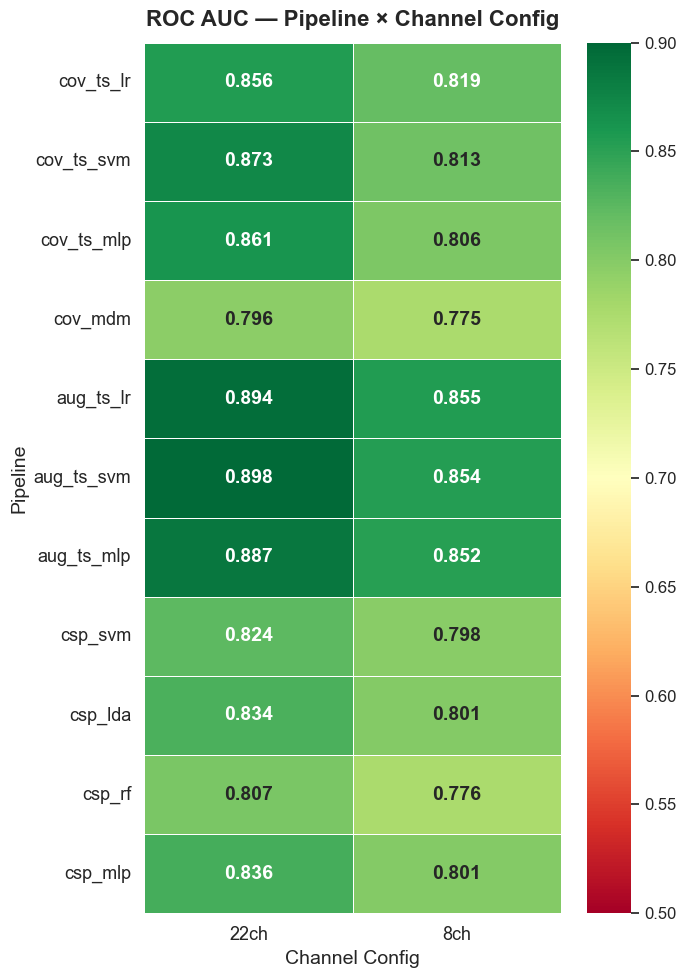

In [10]:
# ── AUC Heatmap ──────────────────────────────────────────────────────────────
pivot = df_means.pivot(index='pipeline', columns='channels', values='roc_auc').loc[PIPE_ORDER]

fig, ax = plt.subplots(figsize=(7, 10))
sns.heatmap(
    pivot, annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0.50, vmax=0.90, linewidths=0.6,
    annot_kws={'size':14,'weight':'bold'}, ax=ax
)
ax.set_title('ROC AUC — Pipeline × Channel Config', fontsize=16, fontweight='bold', pad=12)
ax.set_xlabel('Channel Config', fontsize=14)
ax.set_ylabel('Pipeline', fontsize=14)
ax.tick_params(labelsize=13)
plt.tight_layout()
plt.savefig(MODEL_DIR/f'{DATASET_TAG}_moabb4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


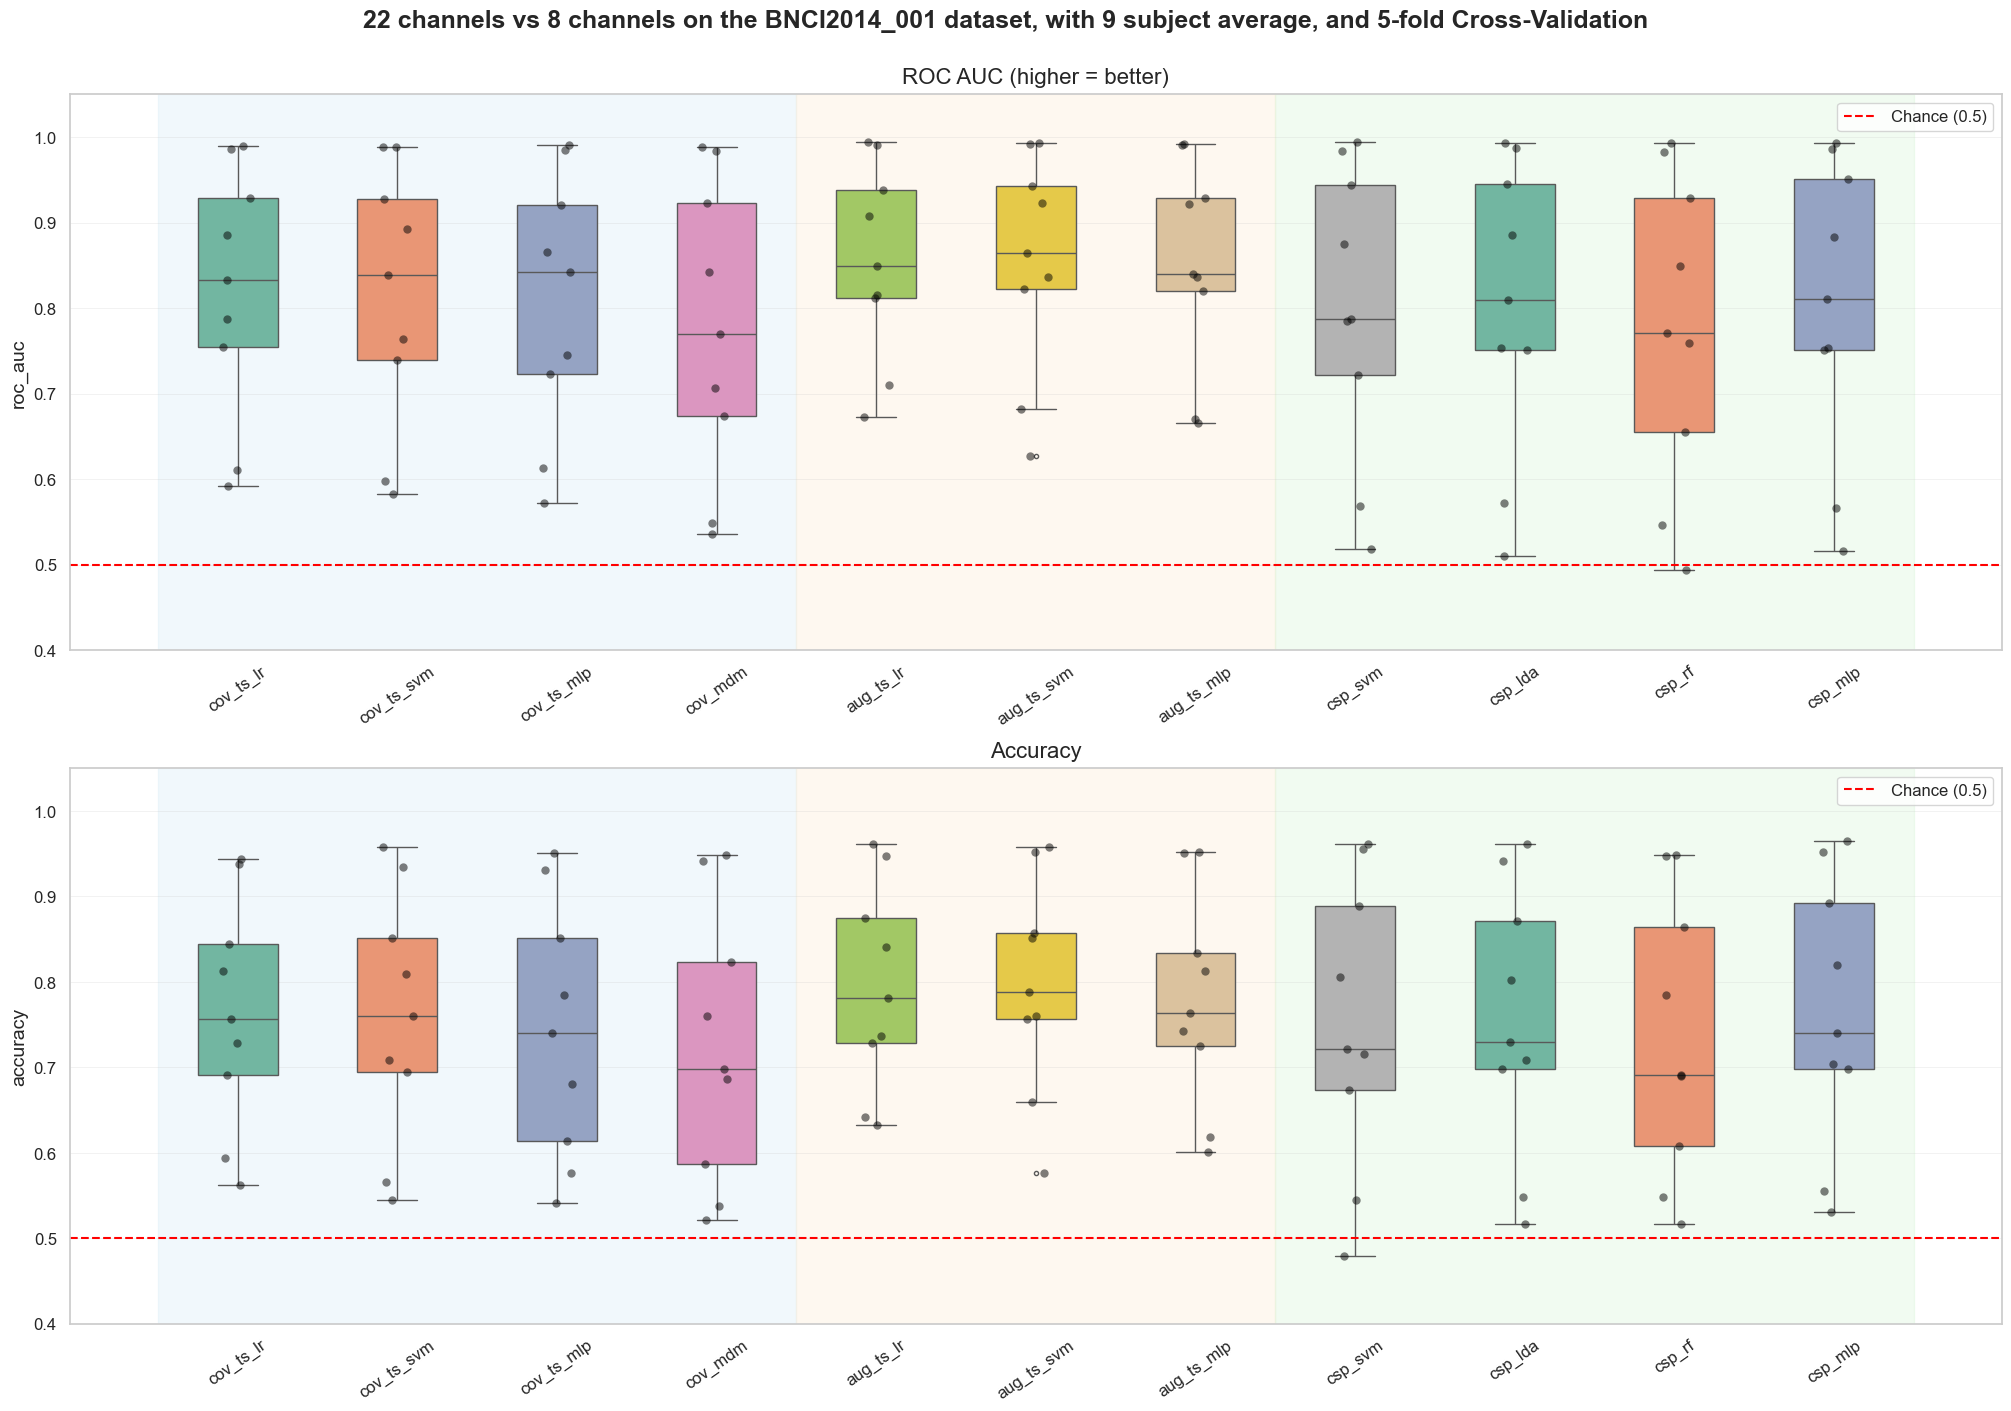

In [ ]:
# ── Per-subject distribution — 8ch ───────────────────────────────────────────
df_8 = df_all[df_all['channels']=='8ch'].copy()

fig, axes = plt.subplots(2, 1, figsize=(20, 14), constrained_layout=True)

# Super title matching the main comparison plot
fig.suptitle('22 channels vs 8 channels on the BNCI2014_001 dataset, with 9 subject average, and 5-fold Cross-Validation\n',
             fontsize=18, fontweight='bold')

metrics = ['roc_auc', 'accuracy']
titles = ['ROC AUC (higher = better)', 'Accuracy (higher = better)']

for ax, metric, title in zip(axes, metrics, titles):
    sns.boxplot(
        data=df_8, x='pipeline', y=metric, order=PIPE_ORDER,
        palette='Set2', width=0.5, ax=ax, fliersize=3
    )
    sns.stripplot(
        data=df_8, x='pipeline', y=metric, order=PIPE_ORDER,
        color='black', alpha=0.5, jitter=True, size=6, ax=ax
    )
    
    ax.axhline(0.5, ls='--', color='red', lw=1.5, label='Chance (0.5)')
    
    # Titles matching the main plot
    ax.set_title(title, fontsize=16, pad=8)
    
    # Label removals and lowercase axes
    ax.set_xlabel('')  # Removes "Pipeline" label
    ax.set_ylabel(metric, fontsize=14) # Keeps "roc_auc" and "accuracy" lowercase
    
    ax.set_ylim(0.40, 1.05)
    ax.tick_params(axis='x', rotation=35, labelsize=12)
    ax.legend(fontsize=12)
    
    # Background shading (distinct colors, no names)
    add_family_shading(ax, PIPE_ORDER, FAMILY)

plt.savefig(MODEL_DIR/f'{DATASET_TAG}_moabb4_subject_dist.png', dpi=150, bbox_inches='tight')
plt.savefig(MODEL_DIR/f'{DATASET_TAG}_moabb4_subject_dist.svg', format='svg', bbox_inches='tight')
plt.show()



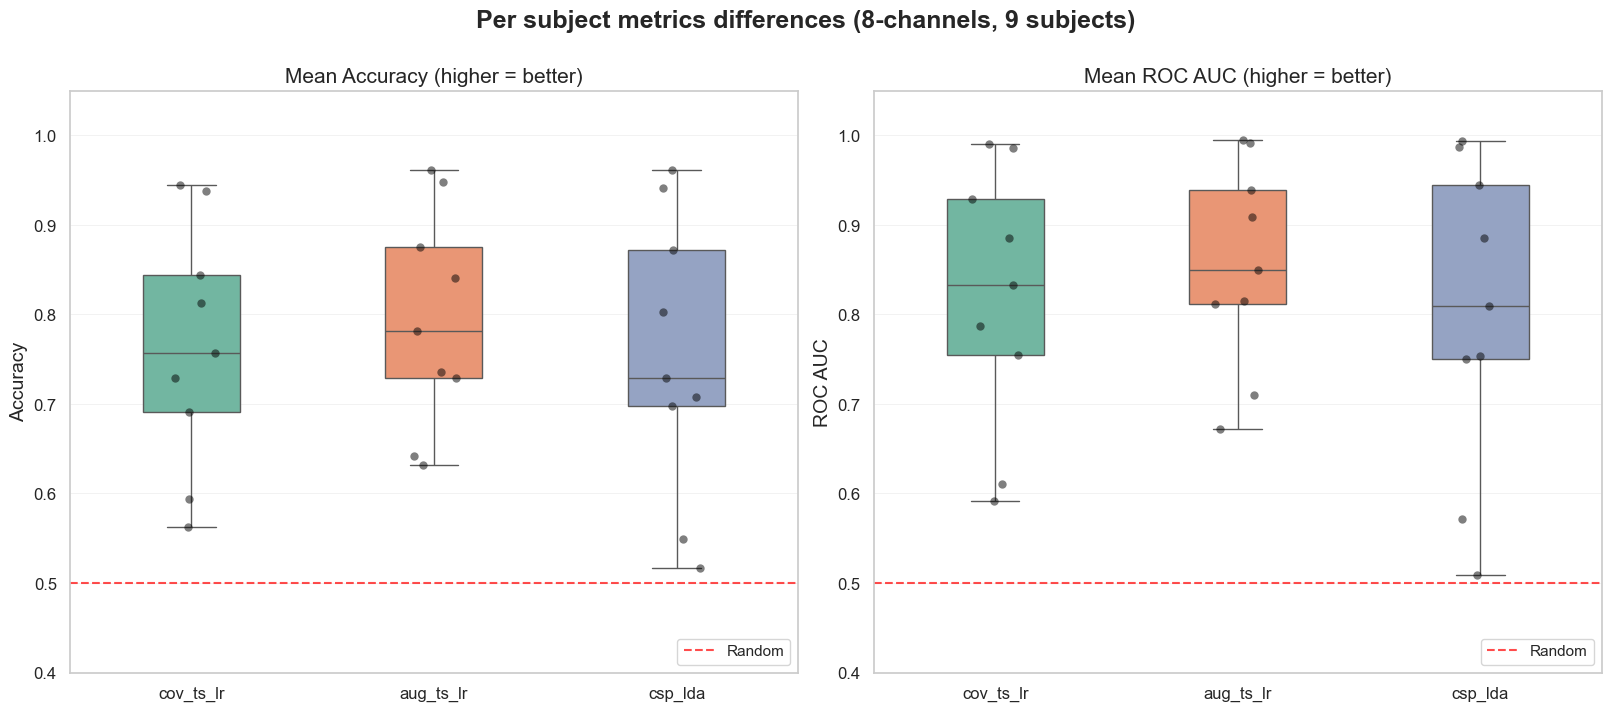

In [34]:
# ── Best Model per Family: 8ch Results for 9 Subjects ────────────────────────
# Selecting the top representative from each family for the 8ch config
top_models = ['cov_ts_lr', 'aug_ts_lr', 'csp_lda'] 
df_top = df_all[(df_all['pipeline'].isin(top_models)) & (df_all['channels'] == '8ch')].copy()

# 2 plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
fig.suptitle('Per subject metrics differences (8-channels, 9 subjects)\n', 
             fontsize=18, fontweight='bold')

metrics = ['accuracy', 'roc_auc']
y_labels = ['Accuracy', 'ROC AUC'] # Capitalized side labels
titles = ['Mean Accuracy (higher = better)', 'Mean ROC AUC (higher = better)']

for ax, metric, y_label, title in zip(axes, metrics, y_labels, titles):
    # Boxplot style with subject dots
    sns.boxplot(data=df_top, x='pipeline', y=metric, order=top_models,
                palette='Set2', width=0.4, ax=ax, fliersize=3)
    sns.stripplot(data=df_top, x='pipeline', y=metric, order=top_models,
                  color='black', alpha=0.5, jitter=True, size=6, ax=ax)
    
    # Red chance line with label
    ax.axhline(0.5, ls='--', color='red', alpha=0.7, label='Random')
    
    ax.set_title(title, fontsize=15)
    ax.set_xlabel('')
    ax.set_ylabel(y_label, fontsize=14) # Set to Accuracy / ROC AUC
    ax.set_ylim(0.4, 1.05)
    
    # Enable legend to show the Chance line label
    ax.legend(fontsize=11, loc='lower right')

plt.savefig(MODEL_DIR/f'{DATASET_TAG}_moabb4_subjects.svg', format='svg', bbox_inches='tight')
plt.show()


2026-05-07 14:21:18,275 INFO MainThread fontTools.subset maxp pruned
2026-05-07 14:21:18,275 INFO MainThread fontTools.subset LTSH dropped
2026-05-07 14:21:18,275 INFO MainThread fontTools.subset cmap pruned
2026-05-07 14:21:18,276 INFO MainThread fontTools.subset kern dropped
2026-05-07 14:21:18,276 INFO MainThread fontTools.subset post pruned
2026-05-07 14:21:18,277 INFO MainThread fontTools.subset PCLT dropped
2026-05-07 14:21:18,277 INFO MainThread fontTools.subset JSTF dropped
2026-05-07 14:21:18,277 INFO MainThread fontTools.subset meta dropped
2026-05-07 14:21:18,283 INFO MainThread fontTools.subset GPOS pruned
2026-05-07 14:21:18,287 INFO MainThread fontTools.subset GSUB pruned
2026-05-07 14:21:18,296 INFO MainThread fontTools.subset glyf pruned
2026-05-07 14:21:18,298 INFO MainThread fontTools.subset Added gid0 to subset
2026-05-07 14:21:18,298 INFO MainThread fontTools.subset Added first four glyphs to subset
2026-05-07 14:21:18,298 INFO MainThread fontTools.subset Closing gl

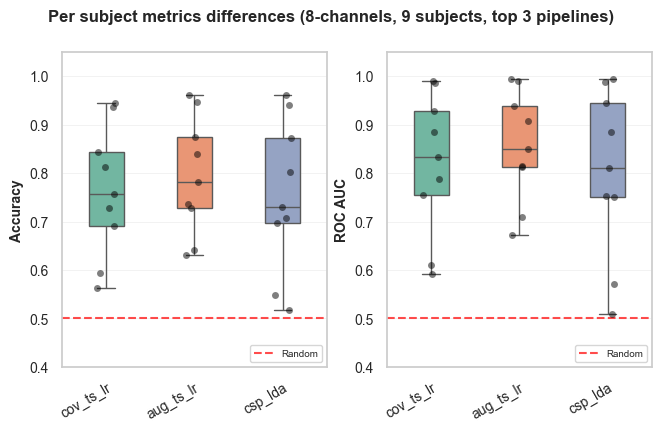

In [100]:
# ── Best Model per Family: 8ch Results (Overleaf/LaTeX Optimized) ───────────
# Selecting the top representative from each family for the 8ch config
top_models = ['cov_ts_lr', 'aug_ts_lr', 'csp_lda'] 
df_top = df_all[(df_all['pipeline'].isin(top_models)) & (df_all['channels'] == '8ch')].copy()

# Force PDF font embedding
mpl.rcParams['pdf.fonttype'] = 42

# 6.5" width matches standard LaTeX text block to prevent font shrinkage
fig, axes = plt.subplots(1, 2, figsize=(6.5, 4.2), constrained_layout=True)

SMALL_FONT = 10
MEDIUM_FONT = 12

fig.suptitle('Per subject metrics differences (8-channels, 9 subjects, top 3 pipelines)', 
             fontsize=MEDIUM_FONT, fontweight='bold')

metrics = ['accuracy', 'roc_auc']
y_labels = ['Accuracy', 'ROC AUC']
titles = ['  ', '  ']

for ax, metric, y_label, title in zip(axes, metrics, y_labels, titles):
    # Boxplot style with subject dots
    sns.boxplot(data=df_top, x='pipeline', y=metric, order=top_models,
                palette='Set2', width=0.4, ax=ax, fliersize=3)
    sns.stripplot(data=df_top, x='pipeline', y=metric, order=top_models,
                  color='black', alpha=0.5, jitter=True, size=5, ax=ax)
    
    # Red chance line
    ax.axhline(0.5, ls='--', color='red', alpha=0.7, label='Random')
    
    # Formatting to match the comparison plot
    ax.set_title(title, fontsize=SMALL_FONT, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(y_label, fontsize=SMALL_FONT, fontweight='bold')
    ax.set_ylim(0.4, 1.05)
    
    # Ticks and alignment
    ax.tick_params(axis='x', rotation=30, labelsize=SMALL_FONT)
    ax.tick_params(axis='y', labelsize=SMALL_FONT)
    plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")
    
    # Legend
    ax.legend(fontsize=SMALL_FONT-3, loc='lower right', frameon=True)

# Export as PDF for maximum quality in LaTeX
plt.savefig(MODEL_DIR/f'{DATASET_TAG}_moabb4_subjects.pdf', bbox_inches='tight')
plt.show()


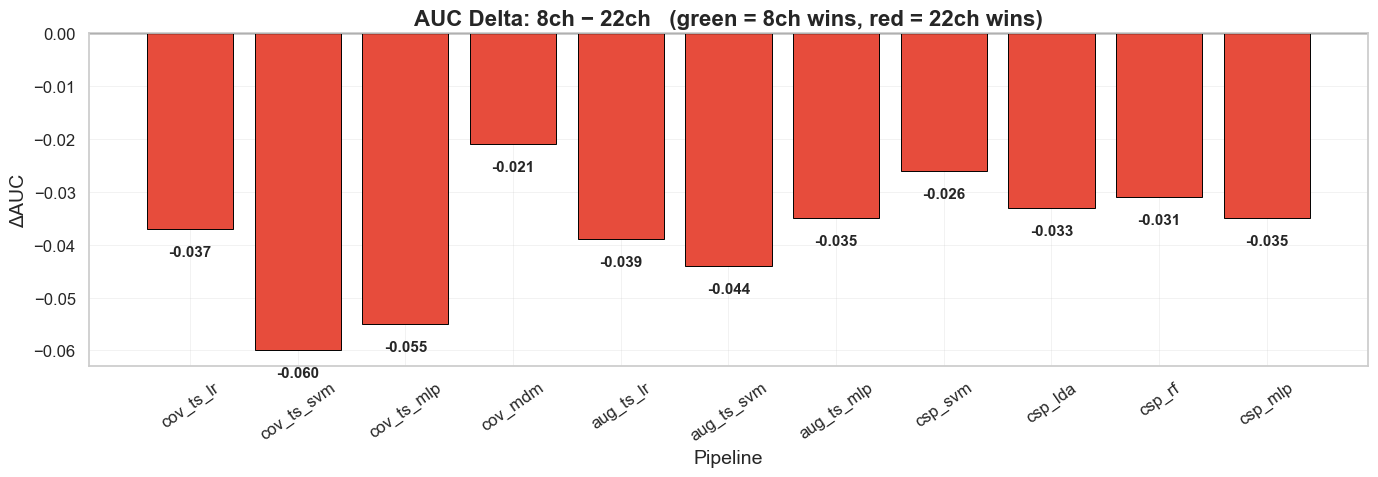

  pipeline  delta_auc   color
   cov_mdm     -0.021 #e74c3c
   csp_svm     -0.026 #e74c3c
    csp_rf     -0.031 #e74c3c
   csp_lda     -0.033 #e74c3c
   csp_mlp     -0.035 #e74c3c
aug_ts_mlp     -0.035 #e74c3c
 cov_ts_lr     -0.037 #e74c3c
 aug_ts_lr     -0.039 #e74c3c
aug_ts_svm     -0.044 #e74c3c
cov_ts_mlp     -0.055 #e74c3c
cov_ts_svm     -0.060 #e74c3c


In [12]:
# ── ΔAUC: 8ch minus 22ch ─────────────────────────────────────────────────────
d8  = df_means[df_means['channels']=='8ch'].set_index('pipeline')['roc_auc']
d22 = df_means[df_means['channels']=='22ch'].set_index('pipeline')['roc_auc']
delta = (d8-d22).loc[PIPE_ORDER].reset_index()
delta.columns = ['pipeline','delta_auc']
delta['color'] = delta['delta_auc'].apply(lambda x: '#2ecc71' if x>=0 else '#e74c3c')

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(delta['pipeline'], delta['delta_auc'],
              color=delta['color'], edgecolor='black', linewidth=0.7)
ax.axhline(0, color='black', lw=1)
ax.set_title('AUC Delta: 8ch − 22ch   (green = 8ch wins, red = 22ch wins)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Pipeline', fontsize=14)
ax.set_ylabel('ΔAUC', fontsize=14)
ax.tick_params(axis='x', rotation=35, labelsize=12)
for bar, v in zip(bars, delta['delta_auc']):
    ax.text(bar.get_x()+bar.get_width()/2,
            v+(0.001 if v>=0 else -0.003),
            f'{v:+.3f}', ha='center',
            va='bottom' if v>=0 else 'top',
            fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(MODEL_DIR/f'{DATASET_TAG}_moabb4_channel_delta.png', dpi=150, bbox_inches='tight')
plt.show()
print(delta.sort_values('delta_auc', ascending=False).to_string(index=False))


In [37]:
# ── Channel Count Comparison: Percentage Differences (22ch vs 8ch) ───────────
# Pivot the means to have both configurations on the same row per pipeline
diff_df = df_means.pivot(index='pipeline', columns='channels', values=['accuracy', 'roc_auc'])

# Calculate relative percentage difference: ((22ch - 8ch) / 8ch) * 100
for metric in ['accuracy', 'roc_auc']:
    diff_df[(metric, '% Diff')] = (
        (diff_df[(metric, '22ch')] - diff_df[(metric, '8ch')]) / diff_df[(metric, '8ch')] * 100
    )

# Reorder columns for a logical flow
cols_ordered = [
    ('accuracy', '8ch'), ('accuracy', '22ch'), ('accuracy', '% Diff'),
    ('roc_auc', '8ch'), ('roc_auc', '22ch'), ('roc_auc', '% Diff')
]
diff_df = diff_df[cols_ordered]

# Add Family info for better grouping
diff_df.insert(0, 'Family', diff_df.index.map(FAMILY))
diff_df = diff_df.sort_values('Family')

# Apply styling: Green for improvement, Red for performance drop
styled_diff = diff_df.style.format({
    (m, '% Diff'): "{:+.2f}%" for m in ['accuracy', 'roc_auc']
}).format({
    (m, c): "{:.3f}" for m in ['accuracy', 'roc_auc'] for c in ['8ch', '22ch']
}).background_gradient(
    cmap='RdYlGn', 
    subset=[(m, '% Diff') for m in ['accuracy', 'roc_auc']],
    vmin=-10, vmax=10
)

display(styled_diff)


In [44]:
# ── Export LaTeX-Safe CSV with 3 Decimal Precision ───────────────────────────
latex_export = diff_df.copy()

# Headers
latex_export.columns = ['Family', 'Acc8', 'Acc22', 'AccDiff', 'AUC8', 'AUC22', 'AUCDiff']
latex_export = latex_export.reset_index().rename(columns={'pipeline': 'Pipeline'})

# Round all numeric columns to 3 decimal places
latex_export = latex_export.round(3)

# Escape underscores in the data for LaTeX
latex_export['Pipeline'] = latex_export['Pipeline'].str.replace('_', r'\_', regex=False)

# Save to CSV
latex_csv_path = MODEL_DIR / "BNCI2014001-channel-comparison.csv"
latex_export.to_csv(latex_csv_path, index=False)

print(f"Rounded LaTeX-safe CSV saved to: {latex_csv_path}")


Rounded LaTeX-safe CSV saved to: e:\GitHub\brainwave-surfers\PythonBCI\models\BNCI2014001-channel-comparison.csv


## 5. Summary Table

In [36]:
best = df_means.sort_values('roc_auc', ascending=False).copy()
best = best[['family','pipeline','channels','roc_auc','accuracy']]
best.columns = ['Family','Pipeline','Channels','ROC AUC','Accuracy']
print('Top 10 configurations:')
display(best.head(10))

print('\nBest per family (8ch only):')
b8 = df_means[df_means['channels']=='8ch'].copy()
b8['family'] = b8['pipeline'].map(FAMILY)
display(b8.sort_values('roc_auc',ascending=False)
         .groupby('family')[['pipeline','roc_auc','accuracy']].first())

print(f'\nResults CSV : {RESULTS_CSV}')
print(f'Figures dir : {MODEL_DIR}')


Top 10 configurations:


,Family,Pipeline,Channels,ROC AUC,Accuracy
4,Aug-TS,aug_ts_svm,22ch,0.898,0.838
0,Aug-TS,aug_ts_lr,22ch,0.894,0.835
2,Aug-TS,aug_ts_mlp,22ch,0.887,0.829
12,Riemannian,cov_ts_svm,22ch,0.873,0.809
10,Riemannian,cov_ts_mlp,22ch,0.861,0.799
8,Riemannian,cov_ts_lr,22ch,0.856,0.790
1,Aug-TS,aug_ts_lr,8ch,0.855,0.794
5,Aug-TS,aug_ts_svm,8ch,0.854,0.796
3,Aug-TS,aug_ts_mlp,8ch,0.852,0.778
16,CSP,csp_mlp,22ch,0.836,0.786



Best per family (8ch only):


,pipeline,roc_auc,accuracy
family,,,
Aug-TS,aug_ts_lr,0.855,0.794
CSP,csp_lda,0.801,0.753
Riemannian,cov_ts_lr,0.819,0.764



Results CSV : e:\GitHub\brainwave-surfers\PythonBCI\models\BNCI2014001_moabb4_results.csv
Figures dir : e:\GitHub\brainwave-surfers\PythonBCI\models
